# Exploring the ALOHA Transfer-Cube Dataset

Dataset documentation: https://huggingface.co/datasets/lerobot/aloha_sim_transfer_cube_human  
LeRobot dataset documentation: https://huggingface.co/docs/lerobot/en/lerobot-dataset-v3

This notebook inspects the ALOHA transfer-cube dataset, a bimanual imitation-learning dataset in which two robot arms pass a cube from one gripper to the other.

In [2]:
from lerobot.datasets import LeRobotDataset

repo_id = "lerobot/aloha_sim_transfer_cube_human"

# Request surrounding camera frames and the next three action targets for each sample.
delta_timestamps = {
    "observation.images.top": [-0.2, 0.1, 0.0],
    "action": [0.0, 0.1, 0.2],
}

# LeRobotDataset downloads and caches the required dataset files locally.
dataset = LeRobotDataset(repo_id, delta_timestamps=delta_timestamps)

Fetching 10 files: 100%|██████████| 10/10 [00:02<00:00,  4.36it/s]


Each item returned by `dataset[index]` is one time-aligned sample, not an entire episode. The available fields and their definitions are recorded in the dataset's [`meta/info.json`](https://huggingface.co/datasets/lerobot/aloha_sim_transfer_cube_human/blob/main/meta/info.json).

Below, we inspect the sample keys, the top-camera tensor and the robot state.

In [14]:
sample = dataset[0]

print(sample.keys())  # All fields available for this time-aligned sample.
print(sample["observation.images.top"].shape)  # [time offsets, channels, height, width]

dict_keys(['observation.images.top', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.done', 'index', 'task_index', 'observation.images.top_is_pad', 'action_is_pad', 'task'])
torch.Size([3, 3, 480, 640])


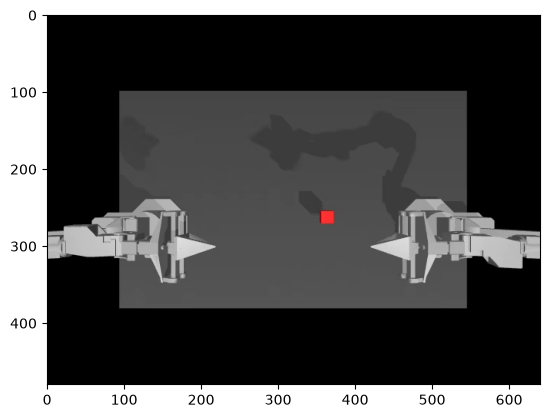

In [15]:
from matplotlib import pyplot as plt

images = sample["observation.images.top"]
current_image = images[-1].permute(1, 2, 0).cpu().numpy()  # Last requested offset is 0.0 seconds.

plt.imshow(current_image)
plt.axis("off")
plt.title("Top-camera observation at t = 0")

`observation.state` contains 14 values in the motor order defined by the dataset metadata:

| Left arm | Right arm |
| --- | --- |
| waist | waist |
| shoulder | shoulder |
| elbow | elbow |
| forearm roll | forearm roll |
| wrist angle | wrist angle |
| wrist rotate | wrist rotate |
| gripper | gripper |

These values describe the measured robot configuration at this point in the episode. Their meaning depends on the dataset's motor ordering, units and conventions; the tensor values are not self-describing.

In [27]:
print(sample["observation.state"])  # Fourteen motor-position values for the current sample.

tensor([ 0.0000, -0.9600,  1.1600,  0.0000, -0.3000,  0.0000,  0.0000,  0.0000,
        -0.9600,  1.1600,  0.0000, -0.3000,  0.0000,  0.0000])


To inspect complete episodes, paste `lerobot/aloha_sim_transfer_cube_human` into the [LeRobot dataset visualizer](https://huggingface.co/spaces/lerobot/visualize_dataset).